In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 檢查 GPU、mps與 CPU 可用性
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0  # normalize
y = mnist['target'].astype(np.int64)

# 分割訓練與測試資料
X_train, X_test, _, _ = train_test_split(X, y, test_size=0.1, random_state=42)

# reshape 成 PyTorch 的影像格式 [batch, channel, height, width]
X_train = torch.tensor(X_train).view(-1, 1, 28, 28)
X_test = torch.tensor(X_test).view(-1, 1, 28, 28)

train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, X_test), batch_size=128, shuffle=False)


In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        # Encoder (Convolutional layers)
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # [1,28,28] -> [32,14,14]
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # [64,7,7]
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_logvar = nn.Linear(64*7*7, latent_dim)

        # Decoder (反卷積層)
        self.fc_dec = nn.Linear(latent_dim, 64*7*7)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # [32,14,14]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # [1,28,28]
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 64, 7, 7)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


# 建立模型
latent_dim = 20
model = CVAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


In [ ]:
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader.dataset):.4f}")


Epoch [1/10], Loss: 149.5808
Epoch [2/10], Loss: 113.1439
Epoch [3/10], Loss: 108.8959
Epoch [4/10], Loss: 106.8758
Epoch [5/10], Loss: 105.6047
Epoch [6/10], Loss: 104.8726
Epoch [7/10], Loss: 104.2030
Epoch [8/10], Loss: 103.6806
Epoch [9/10], Loss: 103.1689
Epoch [10/10], Loss: 102.8109


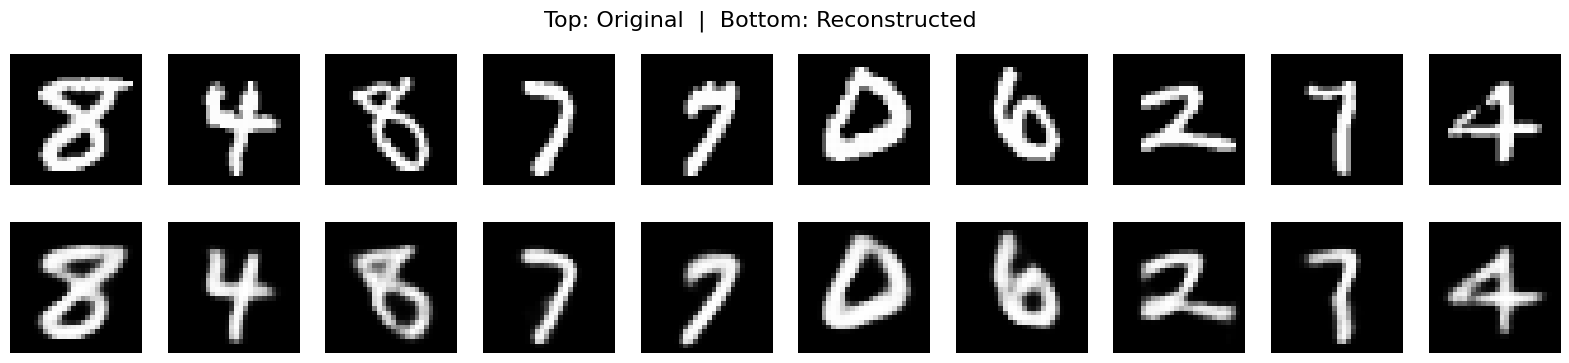

In [ ]:
model.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        recon_x, _, _ = model(x)
        break

# 顯示原始與重建影像
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # 原始
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')

    # 重建
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_x[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Top: Original  |  Bottom: Reconstructed", fontsize=16)
plt.show()


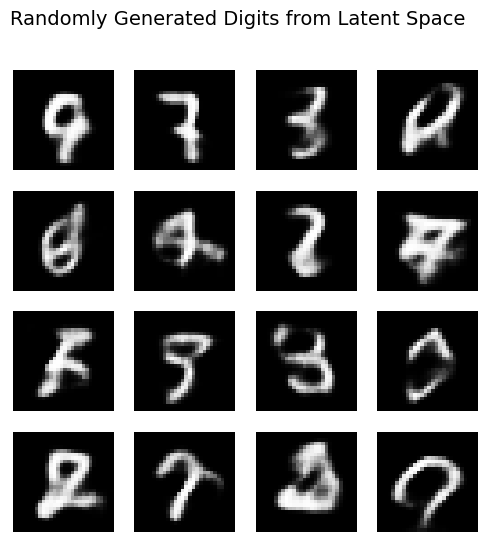

In [ ]:
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    sample = model.decode(z).cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    ax = plt.subplot(4,4,i+1)
    plt.imshow(sample[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Randomly Generated Digits from Latent Space", fontsize=14)
plt.show()
